In [23]:
import os
from pathlib import Path

import json

from yarst_parser import YarstParser
from elins_parser import ElinsParser

PROJECT_FOLDER = Path('C:/MyFolder/PythonProjects/report_maker/MMK_degr_new_electrolyte')
# PROJECT_FOLDER = Path('C:/MyFolder/PythonProjects/report_maker/MMK_ST_ProjEltest21')

metrics_path = PROJECT_FOLDER / '03_Processed_data' / 'step_metrics.csv'
results_path = PROJECT_FOLDER / '04_Results' 
cycles_path = PROJECT_FOLDER / '02_Parsed_data' / 'potentiostat' / 'cycles.txt'
ocv_path = PROJECT_FOLDER / '03_Processed_data' / 'ocv_measurements.csv'

densities_cyc_img_path = results_path / 'densities_ch-dch.png'
densities_eff_img_path = results_path / 'densities_efficiencies.png'
densities_ocv_img_path = results_path / 'densities_ocv.png'
long_cyc_img_path = results_path / 'long_ch-dch.png'
long_eff_img_path = results_path / 'long_efficiencies.png'
long_ocv_img_path = results_path / 'long_ocv.png'


config = json.load(open(PROJECT_FOLDER / 'config.json', 'r', encoding='utf-8'))


In [24]:
# capacity calculation

if config['experiment_info']['potentiostat'] == 'Elins':
    parser = ElinsParser(PROJECT_FOLDER)
else:
    parser = YarstParser(PROJECT_FOLDER)

C_nom_coulombs, C_nom_Ah = parser.calculate_nominal_capacity()

print(f"Теоретическая ёмкость аккумулятора: {C_nom_coulombs} Кл или {C_nom_Ah} А*ч")


Теоретическая ёмкость аккумулятора: 5403.160000000001 Кл или 1.500877777777778 А*ч


In [25]:
from post_processing import reshape_ocv_data
# cycles parsing

if parser.config['experiment_info']['potentiostat'] == 'Yarst':
    parser.read_data(parser.raw_data_path / 'potentiostat')

elif parser.config['experiment_info']['potentiostat'] == 'Elins':
    parser.read_data(parser.raw_data_path / 'potentiostat' / 'potentiostat.txt')

parser.process_data(parser.data)
parser.write_csv_data(parser.data, cycles_path)

ocv_df = reshape_ocv_data(ocv_path)

Q = 16.628102709833335 mA*h, <U> = 0.7906730367839272 V, E = 13.147392465538973
Q = 1108.044385911111 mA*h, <U> = 1.2732454702854377 V, E = 1410.8124952365315
Q = 139.4083473824 mA*h, <U> = 1.6494568708823598 V, E = 229.9480564482545
Block 1, Cycle 1, Step 4 is skipped (I==0)
V = 0.035, Cb = 1.6
OCV = 1.61806499958
Block 2, Cycle 1, Step 1 is skipped (I==0)
V = 0.035, Cb = 1.6
OCV = 1.617462038994
Q = -1113.4978797694446 mA*h, <U> = 1.2485181360244857 V, E = -1390.222297316964
Block 2, Cycle 1, Step 3 is skipped (I==0)
V = 0.035, Cb = 1.6
OCV = 1.300037026405
Q = -4.802517427338889 mA*h, <U> = 0.599591970444 V, E = -2.879550887349774
Block 2, Cycle 1, Step 5 is skipped (I==0)
V = 0.035, Cb = 1.6
OCV = 1.300238013268
Q = 1163.4972140192278 mA*h, <U> = 1.5067193021524192 V, E = 1753.0637103633348
Block 3, Cycle 1, Step 2 is skipped (I==0)
V = 0.035, Cb = 1.6
OCV = 1.524443984032
Q = -1106.4837416019334 mA*h, <U> = 1.2826423405446328 V, E = -1419.2228961028866
Block 3, Cycle 1, Step 4 is 

In [26]:
# efficiency calculations
from post_processing import calculate_efficiencies, plot_efficiencies

eff_df = calculate_efficiencies(metrics_path)
eff_df.to_csv(PROJECT_FOLDER / '03_Processed_data' / 'efficiencies.csv')



График успешно сохранен в файл: C:\MyFolder\PythonProjects\report_maker\MMK_degr_new_electrolyte\04_Results\densities_ch-dch.png


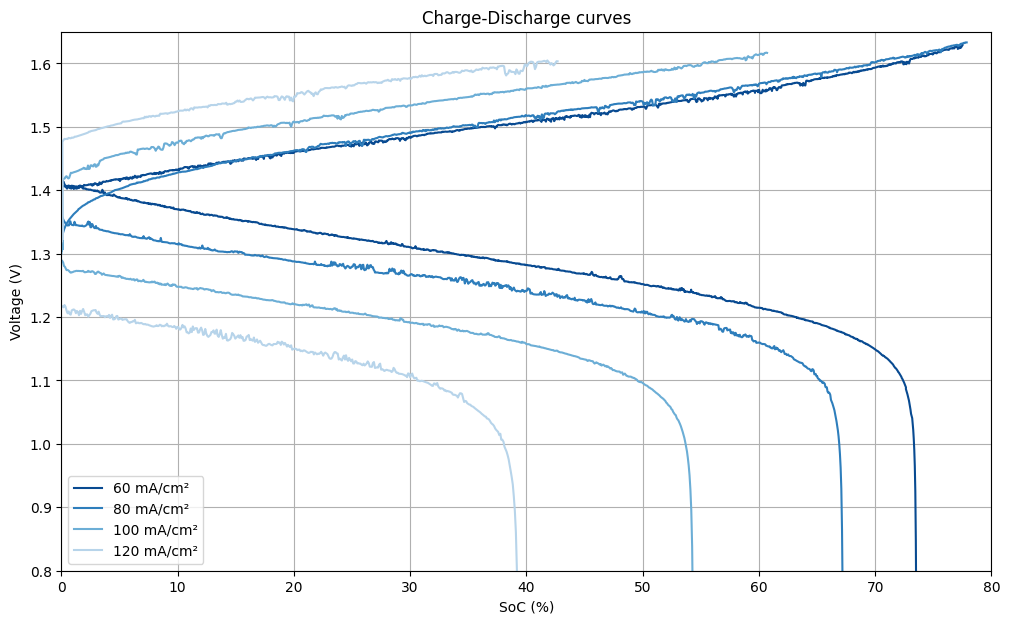

График успешно сохранен в файл: C:\MyFolder\PythonProjects\report_maker\MMK_degr_new_electrolyte\04_Results\densities_efficiencies.png


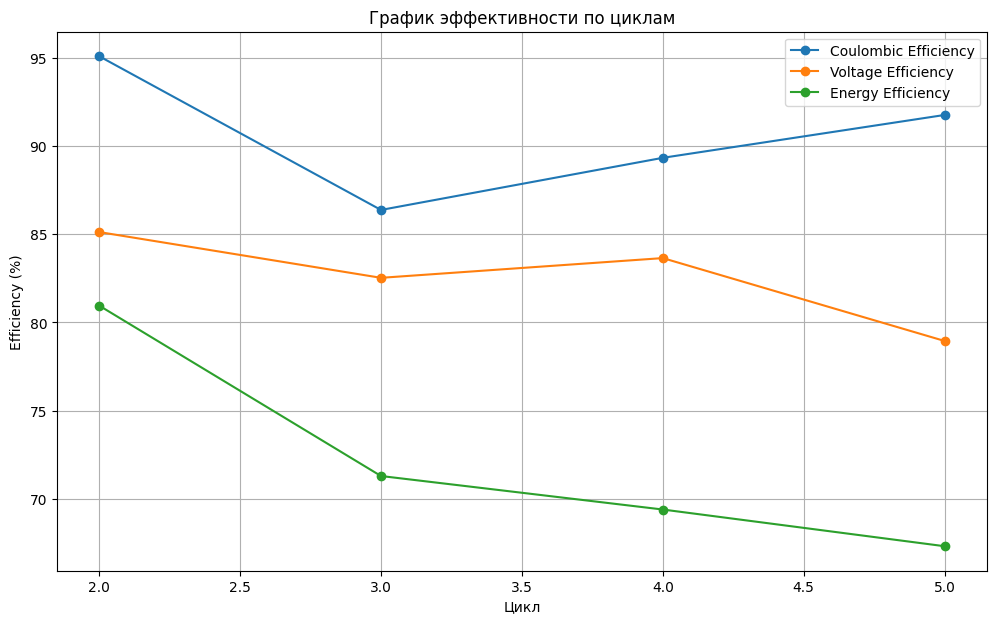

График успешно сохранен в файл: C:\MyFolder\PythonProjects\report_maker\MMK_degr_new_electrolyte\04_Results\densities_ocv.png


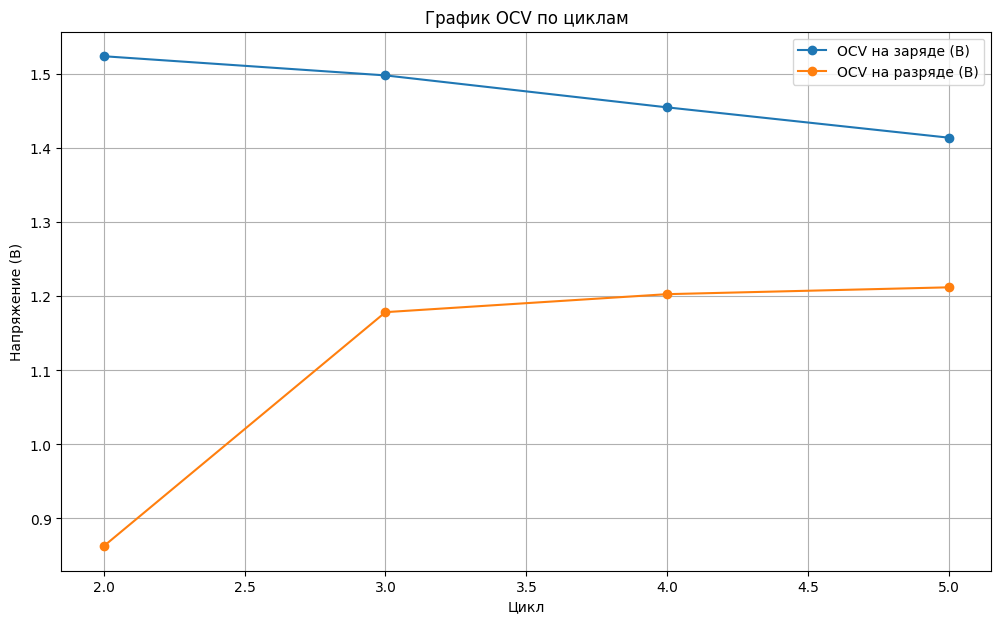

In [27]:
from post_processing import plot_charge_discharge_cycles, get_total_cycles, plot_ocv

plot_charge_discharge_cycles(cycles_path, C_nom_coulombs, densities_cyc_img_path,
                             2, 5,
                             current_densities=[60, 80, 100, 120])

plot_efficiencies(eff_df.iloc[1:5], densities_eff_img_path)

plot_ocv(ocv_df[1:5], densities_ocv_img_path)


График успешно сохранен в файл: C:\MyFolder\PythonProjects\report_maker\MMK_degr_new_electrolyte\04_Results\long_ch-dch.png


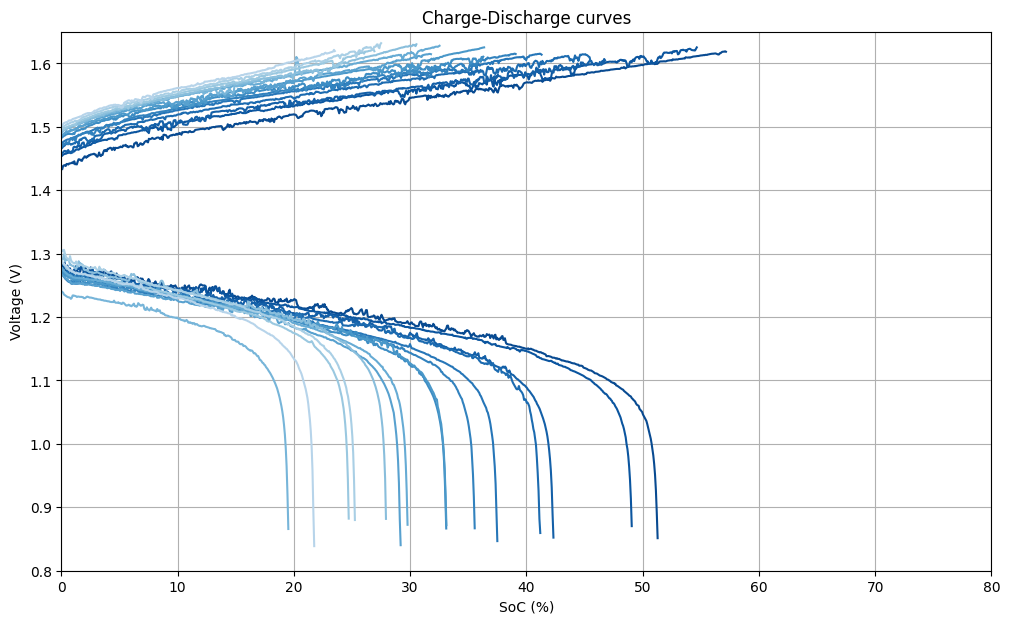

График успешно сохранен в файл: C:\MyFolder\PythonProjects\report_maker\MMK_degr_new_electrolyte\04_Results\long_efficiencies.png


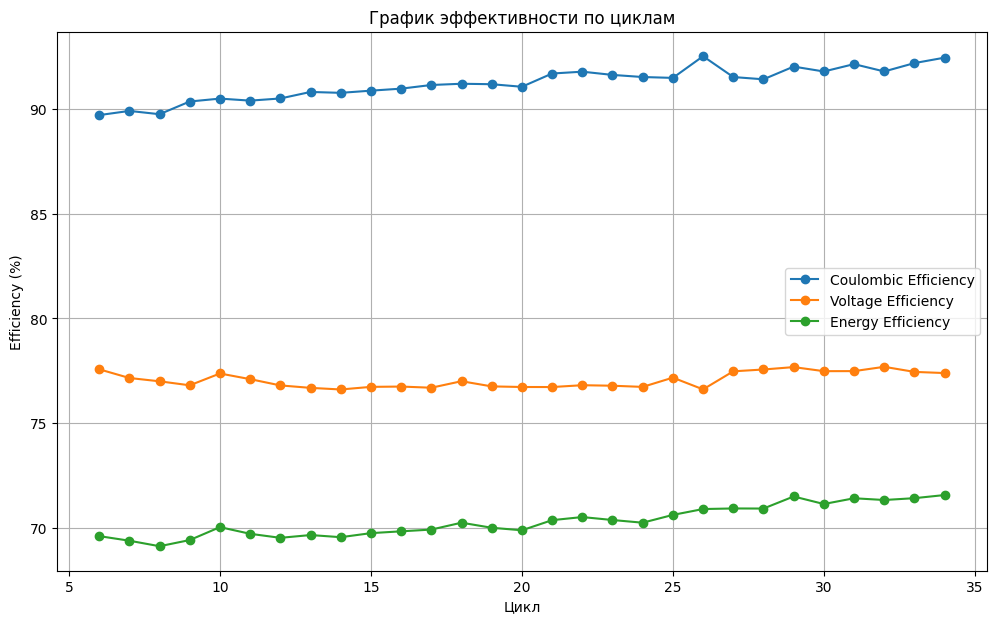

График успешно сохранен в файл: C:\MyFolder\PythonProjects\report_maker\MMK_degr_new_electrolyte\04_Results\long_ocv.png


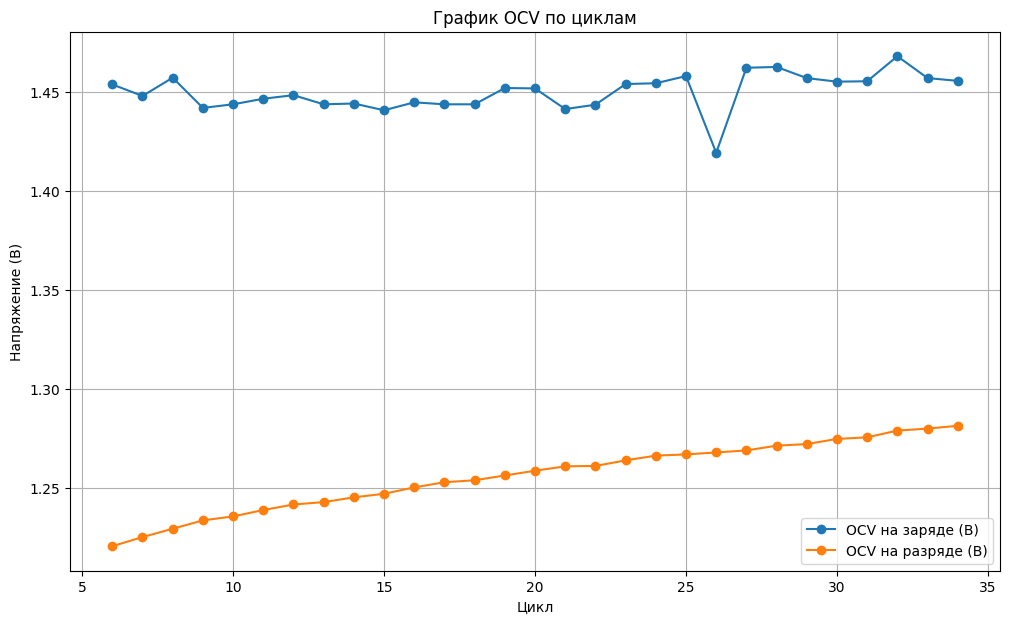

In [28]:
plot_charge_discharge_cycles(cycles_path, C_nom_coulombs, long_cyc_img_path,
                             6, get_total_cycles(cycles_path)-1, 
                             cycle_step=2, plot_legend=False)

plot_efficiencies(eff_df.iloc[5:-1], long_eff_img_path)
plot_ocv(ocv_df[5:-1], long_ocv_img_path)
